In [26]:
# %%
import sys
sys.path.insert(0, '..')
import helper_functions
from constants import *

import eelbrain
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

In [27]:
# %%
# Configure matplotlib style
helper_functions.set_plot_style()

In [28]:
# %%
# Load backward envelope TRFs for all subjects
SUBJECTS = helper_functions.get_subjects()

att_name = helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD)
ign_name = helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD)

trfs     = []
r_values = []

for subject in SUBJECTS:
    att_path = SELF_COMPUTED_TRF_DIR / subject / f"{subject}_{att_name}_trf.pickle"
    ign_path = SELF_COMPUTED_TRF_DIR / subject / f"{subject}_{ign_name}_trf.pickle"

    if not (att_path.exists() and ign_path.exists()):
        print(f"{subject}: missing files, skipping.")
        continue

    trf_att = eelbrain.load.unpickle(att_path)
    trf_ign = eelbrain.load.unpickle(ign_path)

    trfs.append((trf_att, trf_ign))
    r_values.append((trf_att.r, trf_ign.r))
    print(f"  ✓ Loaded {subject}")

print(f"Loaded TRFs for {len(trfs)} subjects")

  ✓ Loaded S1
  ✓ Loaded S2
  ✓ Loaded S3
  ✓ Loaded S4
  ✓ Loaded S5
  ✓ Loaded S6
  ✓ Loaded S7
  ✓ Loaded S8
  ✓ Loaded S9
  ✓ Loaded S10
  ✓ Loaded S11
  ✓ Loaded S12
  ✓ Loaded S13
  ✓ Loaded S14
  ✓ Loaded S15
  ✓ Loaded S16
  ✓ Loaded S17
  ✓ Loaded S18
Loaded TRFs for 18 subjects


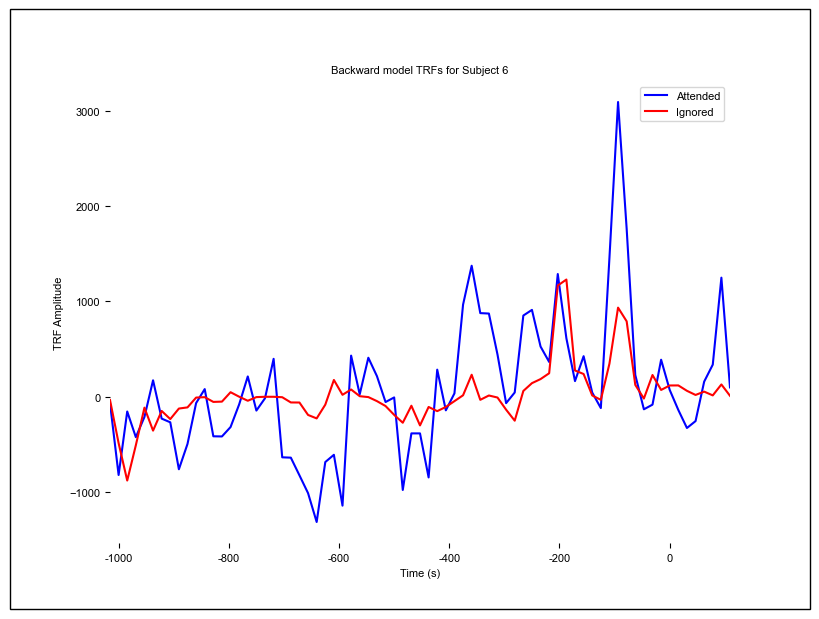

In [29]:
# %%
# Single subject TRF plot
SUBJECT_NUMBER   = 6
att_trf_mean     = trfs[SUBJECT_NUMBER - 1][0].h_scaled.mean('sensor')
ign_trf_mean     = trfs[SUBJECT_NUMBER - 1][1].h_scaled.mean('sensor')

fig, ax = plt.subplots(1, figsize=(8, 6), subplot_kw=dict(frame_on=False))
eelbrain.plot.UTS(att_trf_mean, axes=ax, color='blue')
eelbrain.plot.UTS(ign_trf_mean, axes=ax, color='red')

ymin   = min(att_trf_mean.x.min(), ign_trf_mean.x.min())
ymax   = max(att_trf_mean.x.max(), ign_trf_mean.x.max())
margin = 0.05 * (ymax - ymin)
ax.set_ylim(ymin - margin, ymax + margin)
ax.legend(['Attended', 'Ignored'], loc='upper right')
ax.set_title(f'Backward model TRFs for Subject {SUBJECT_NUMBER}')
ax.set_ylabel('TRF Amplitude')
ax.set_xlabel('Time (s)')

eelbrain.plot.figure_outline()
fig.savefig(FIGURES_DIR / f'{FUGLSANG}_comparison_attended_ignored.png', bbox_inches='tight')

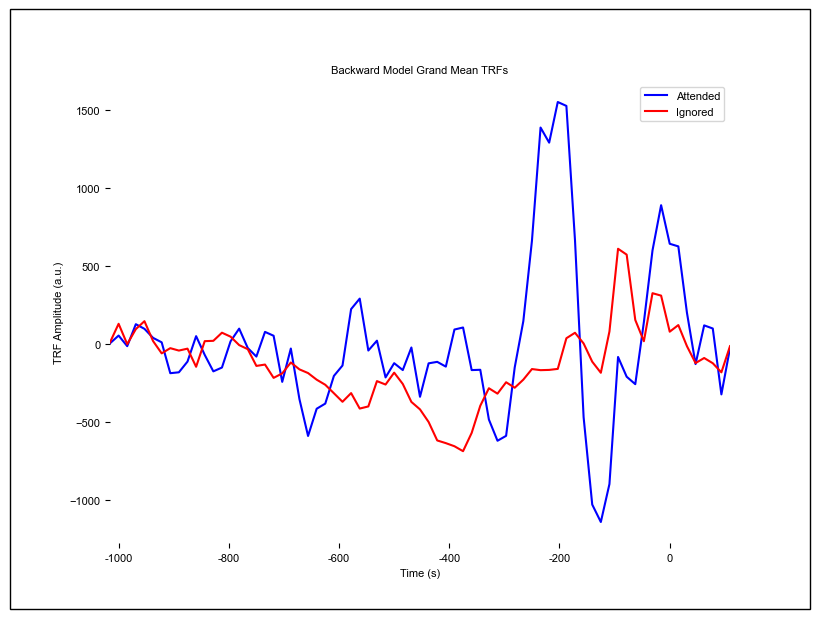

In [30]:
# %%
# Grand mean TRF plot
att_trf_means      = [trf[0].h_scaled.mean('sensor') for trf in trfs]
ign_trf_means      = [trf[1].h_scaled.mean('sensor') for trf in trfs]
grand_att_mean     = eelbrain.combine(att_trf_means).mean('case')
grand_ign_mean     = eelbrain.combine(ign_trf_means).mean('case')

fig, ax = plt.subplots(1, figsize=(8, 6), subplot_kw=dict(frame_on=False))
eelbrain.plot.UTS(grand_att_mean, axes=ax, color='blue')
eelbrain.plot.UTS(grand_ign_mean, axes=ax, color='red')

ymin   = min(grand_att_mean.x.min(), grand_ign_mean.x.min())
ymax   = max(grand_att_mean.x.max(), grand_ign_mean.x.max())
margin = 0.05 * (ymax - ymin)
ax.set_ylim(ymin - margin, ymax + margin)
ax.legend(['Attended', 'Ignored'], loc='upper right')
ax.set_title('Backward Model Grand Mean TRFs')
ax.set_ylabel('TRF Amplitude (a.u.)')
ax.set_xlabel('Time (s)')

eelbrain.plot.figure_outline()
fig.savefig(FIGURES_DIR / f'{FUGLSANG}_backward_model_trfs_comparison.png', bbox_inches='tight')

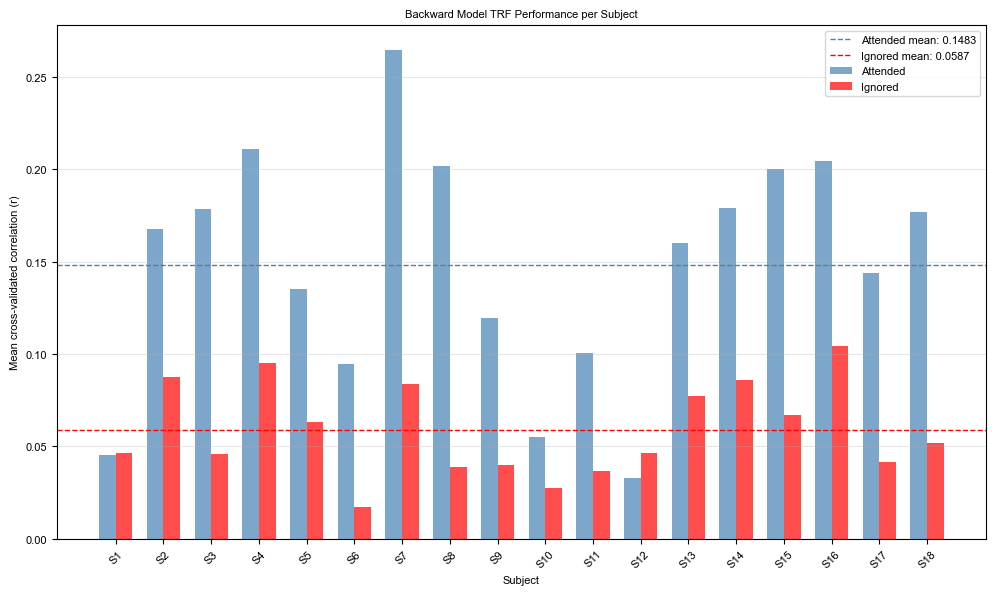

In [31]:
# %%
# Per-subject bar plot
mean_att_r = [r_att.mean() for (r_att, _) in r_values]
mean_ign_r = [r_ign.mean() for (_, r_ign) in r_values]

fig, ax = plt.subplots(figsize=(10, 6))
x     = np.arange(len(mean_att_r))
width = 0.35

ax.bar(x - width/2, mean_att_r, width, color='steelblue', alpha=0.7, label='Attended')
ax.bar(x + width/2, mean_ign_r, width, color='red',       alpha=0.7, label='Ignored')
ax.axhline(np.mean(mean_att_r), color='steelblue', linestyle='--', linewidth=1, label=f'Attended mean: {np.mean(mean_att_r):.4f}')
ax.axhline(np.mean(mean_ign_r), color='red',       linestyle='--', linewidth=1, label=f'Ignored mean: {np.mean(mean_ign_r):.4f}')

ax.set_xlabel('Subject')
ax.set_ylabel('Mean cross-validated correlation (r)')
ax.set_title('Backward Model TRF Performance per Subject')
ax.set_xticks(x)
ax.set_xticklabels([f'S{i+1}' for i in range(len(mean_att_r))], rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / f'{FUGLSANG}_backward_model_trf_per_subject.png', bbox_inches='tight')
plt.show()

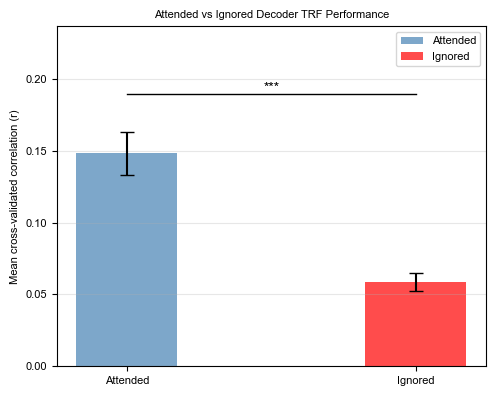

In [32]:
# %%
# Group summary bar plot with statistics
mean_vals = [np.mean(mean_att_r), np.mean(mean_ign_r)]
sem_vals  = [stats.sem(mean_att_r), stats.sem(mean_ign_r)]
t, p      = stats.ttest_rel(mean_att_r, mean_ign_r)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(0, mean_vals[0], 0.35, yerr=sem_vals[0], capsize=5, color='steelblue', alpha=0.7, label='Attended')
ax.bar(1, mean_vals[1], 0.35, yerr=sem_vals[1], capsize=5, color='red',       alpha=0.7, label='Ignored')

y_max = max(mean_vals[0] + sem_vals[0], mean_vals[1] + sem_vals[1])
helper_functions.add_sig_line(ax, 0, 1, y_max + 0.16 * y_max, helper_functions.sig_marker(p))

ax.set_xticks([0, 1])
ax.set_xticklabels(['Attended', 'Ignored'])
ax.set_ylabel('Mean cross-validated correlation (r)')
ax.set_title('Attended vs Ignored Decoder TRF Performance')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, y_max * 1.45)

plt.tight_layout()
fig.savefig(FIGURES_DIR / f'{FUGLSANG}_decoder_rbar_attended_vs_ignored.png', bbox_inches='tight')
plt.show()

In [33]:
# %%
# LaTeX results summary
print("% Results summary (LaTeX)")
print(r"\textbf{Mean correlation (r):} Attended = %.4f, Ignored = %.4f" % (mean_vals[0], mean_vals[1]))
print(r"\textbf{Statistical tests:}")
print(r"\begin{itemize}")
print(r"  \item Attended vs. Ignored: $t(%d) = %.2f$, $p = %.3g$" % (len(mean_att_r) - 1, t, p))
print(r"\end{itemize}")

% Results summary (LaTeX)
\textbf{Mean correlation (r):} Attended = 0.1483, Ignored = 0.0587
\textbf{Statistical tests:}
\begin{itemize}
  \item Attended vs. Ignored: $t(17) = 7.50$, $p = 8.74e-07$
\end{itemize}
